## Υπολογιστική Εργασία Ι: Το απειρόβαθο τετραγωνικό πηγάδι

Το άπειρο τετραγωνικό πηγάδι είναι ένα από τα λίγα προβλήματα της κβαντικής μηχανικής που μπορούν εύκολα να λυθούν σε έναν πίνακα. Αυτό το καθιστά το συνηθισμένο σημείο εκκίνησης για την εισαγωγή κβαντικών εννοιών όπως τα επίπεδα ενέργειας, η υπέρθεση και οι στατικές καταστάσεις.  Επιπλέον, το να έχουμε τις «ακριβείς» απαντήσεις καθιστά το πρόβλημα του απειρόβαθου τετραγωνικού πηγαδιού ένα μεγάλο εισαγωγικό υπολογιστικό πρόβλημα, αφού μπορούμε εύκολα να ελέγξουμε ότι το πρόγραμμά μας λειτουργεί σωστά.

Σε αυτή την εργασία θα:
1. Σχεδιάστε τα χωρικά μέρη ιδιοκαταστάσεων άπειρόβαθων τετραγωνικών πηγαδιών
* Θα απεικονίσετε με animation τη χρονική εξάρτηση των ιδιοσυναρτήσεων
* Σχηματίστε μια υπέρθεση ιδιοκαταστάσεων και θα απεικονίσετε με animation τη χρονική του εξέλιξη

Κάθε τμήμα κώδικα που πρέπει να τροποποιήσετε φέρει την ένδειξη "Ερώτηση".

### Ανασκόπηση του απειρόβαθου τετραγωνικού πηγαδιού

Ας αναθεωρήσουμε τις εξισώσεις που θα χρειαστούμε. Σύμφωνα με όσα γνωρίζουμε, για ένα ΑΤΠ που βρίσκεται μεταξύ $x=0$ και $x=a$, οι λύσεις της χρονικά ανεξάρτητης εξίσωσης Schrodinger είναι
$$\psi_n(x)=\sqrt{\frac{2}{a}}\sin \left( \frac{n\pi}{a}x \right)$$
$$E_n = \frac{n^2\pi^2\hbar^2}{2ma^2}$$
$$\Psi_n(x,t)=\psi_n(x)e^{-iE_nt/\hbar}$$

Επομένως, μια αυθαίρετη κατάσταση σε ένα ΑΤΠ μπορεί να γραφτεί ως υπέρθεση αυτών των ιδιοκαταστάσεων.
$$\Psi(x,t)=\sum_{n=1}^{\infty} c_n \psi_n(x)e^{-iE_nt/\hbar}$$
$$c_n=\int \psi_n^*(x) \Psi(x,t)dx$$
$$\sum_{n=1}^{\infty}|c_n|^2=1$$

### Χρονικές κλίμακες και μικροί αριθμοί

Οι υπολογιστές εκτελούν πράξεις με μεγάλη ακρίβεια, αλλά συχνά έχουν πρόβλημα με πολύ μεγάλους ή πολύ μικρούς αριθμούς.  Θα θέλαμε να έχουμε μια λογική κλίμακα, αποφεύγοντας άξονες με αριθμούς όπως $1,6\times10^{-23}$.  Η σταθερά του Planck ($\hbar$), οι μάζες σωματιδίων ($m$) και οι ατομικές αποστάσεις ($a$) είναι πολύ μικροί αριθμοί σε μονάδες και θα θέλαμε να έχουμε μια αίσθηση της κλίμακας με την οποία εργαζόμαστε πριν αρχίσουμε τον προγραμματισμό  Αν κοιτάξετε τους παραπάνω τύπους, θα δείτε ότι ο παράγοντας ενεργειακής φάσης καθορίζει τη χρονική κλίμακα.
$$\exp\left( -i E_n t/ \hbar\right) = \exp\left( -i \frac{n^2 \pi^2 \hbar}{2ma^2}t \right)$$

In [137]:
from IPython import get_ipython     # για εκκαθαρισμό μεταβλητών μεταξύ ασκήσεων με την παρακάτω εντολή (εγκατάσταση με pip install ipython)
%reset -sf

#### Ερώτηση 1
Ας υποθέσουμε ότι ένα ηλεκτρόνιο περιορίζεται σε ένα ΑΤΠ με $a=1 A. (1 A =10^{-10}m)$.  Ποια είναι η περίοδος $T$ του συντελεστή φάσης για τη βασική κατάσταση;

In [138]:
import numpy as np

def E(n):           return (n * np.pi * hbar / a) ** 2 / (2 * m)
def T(n):           return 2 * np.pi * hbar / E(n)

ang = 1e-10             # Angstrom

n = 1                   # Βασική κατάσταση
a = 1 * ang             # Πλάτος πηγαδιού
m = 9.1e-31             # Μάζα ηλεκτρονίων
hbar = 1.0545718e-34    # Η σταθερά του Planck διαιρεμένη με 2pi

T = T(n)                # Η περίοδος

print("The period is T =",f'{T*10**16:.3f}', "* 10^-16 seconds")


The period is T = 1.099 * 10^-16 seconds


Βλέπουμε ότι οι τυπικές χρονικές κλίμακες για ένα πραγματικό σύστημα είναι πολύ μικρές, επομένως θα επιλέξουμε μονάδες που μας επιτρέπουν να εργαστούμε με λογικούς αριθμούς.  Για το υπόλοιπο notebook, θα δουλέψουμε  σε μια νέα χρονική κλίμακα, $$\tau = \frac{\hbar}{ma^2}t$$ και επιπλέον ας πούμε ότι $a=1m$.

In [139]:
a = 1
def tau(t): return hbar * t / (m * a**2)

### Προγραμματισμός των Ιδιοσυναρτήσεων

Ας γράψουμε μερικές συναρτήσεις για να λάβουμε τις ιδιοκαταστάσεις του ΑΤΠ ως arrays np.  Πρώτα χρειαζόμαστε μια array που αντιπροσωπεύει το χώρο μας, $x=0$ έως $x=a=1$.

In [140]:
spacing = 1e-3
x = np.arange(0, 1, spacing)   
N = len(x)         # Αριθμός συντεταγμένων

#### Ερώτηση 2
Γράψτε μια συνάρτηση που παίρνει το $x$, σε χωρικές συντεταγμένες, και $n$, το δείκτη της ιδιοκατάστασης, και να επιστρέφει το χωρικό τμήμα της $n^{ιοστης}$ ιδιοσυνάρτησης, $\psi_n(x)$. 

In [141]:
def psi_n_x(n, x):          return np.sqrt(2 / a) * np.sin(n * np.pi * x / a)

Εντάξει, τώρα ας ελέγξουμε τη συνάρτησή μας για $\psi_n(x)$.  Θα το κάνουμε αυτό με δύο τρόπους,
1. Ελέγχουμε ότι έχει κανονικοποιηθεί σωστά

Εδώ έχουμε μια συνάρτηση (norm) που θα πάρει μια συνάρτηση (με τη μορφή ενός πίνακα np) και θα επιστρέψει το ολοκλήρωμα του τετραγώνου της, ή αλλιώς την norm.

In [142]:
def norm(dx, f): return dx*np.dot(f,np.conjugate(f))

#### Ερώτηση 3
Ο παρακάτω κώδικας θα υπολογίσει τον κανόνα της ιδιοκατάστασης $n^{th}$ και θα σχεδιάσει τόσο την κυματοσυνάρτηση όσο και την κατανομή πιθανότητας.  Αλλάξτε το $n$ για να ελέγξετε μερικές διεγερμένες καταστάσεις.  Φαίνεται ότι το $\psi_n(x)$ σας είναι σωστό;  Γράψτε το σκεπτικό σας στο κελί Markdown κάτω από τις γραφικές παραστάσεις.

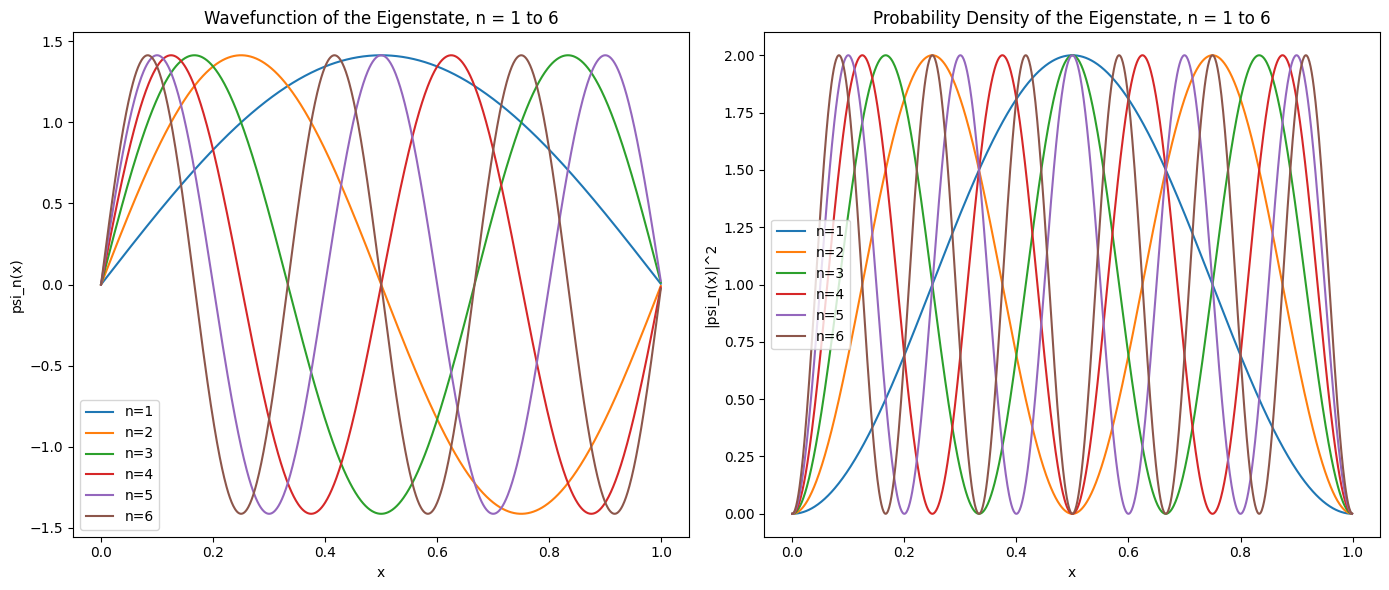

In [143]:
# %matplotlib ipympl
import matplotlib
import matplotlib.pyplot as plt 

n = 6
psi_test = psi_n_x(n, x)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i in range(1, n + 1):
    psi_test = psi_n_x(i, x)
    axes[0].plot(x, psi_test, label=f"n={i}")
    axes[1].plot(x, psi_test * np.conjugate(psi_test), label=f"n={i}")  # για να είναι πιθανότητα, πρέπει να πολλαπλασιαστεί με * a/2

axes[0].set_xlabel("x")
axes[0].set_ylabel("psi_n(x)")
axes[0].set_title("Wavefunction of the Eigenstate, n = 1 to "+str(n))
axes[0].legend()

axes[1].set_xlabel("x")
axes[1].set_ylabel("|psi_n(x)|^2")
axes[1].set_title("Probability Density of the Eigenstate, n = 1 to "+str(n))
axes[1].legend()

plt.tight_layout()
plt.show()

#### Γράψτε την απάντησή σας στην Ερώτηση 3 εδώ

Από τα παραπάνω διαγράμματα φαίνεται ότι η μοντελοποίηση της συνάρτησης ψ(x) είναι ορθή. Αριστερά βλέπουμε ότι οι κυματοσυναρτήσεις είναι ημιτονοειδείς με n ακρότατα (κορυφές) και πλάτος από 0 έως 1.41, που είναι ίσο με ρίζα (2/a) για a = 1. Οι συναρτήσεις αρχίζουν και τελειώνουν στο 0 οπότε τα όρια είναι καλά ορισμένα, και οι επιτρεπόμενες κυματοσυναρτήσεις χωράνε ακριβώς στο πηγάδι δυναμικού.

Δεξιά παρατηρούμε ότι η πυκνότητα πιθανότητας έχει ίδια μορφή με το τετράγωνο της ψ(x), κάτι που αναμένεται από τον ορισμό της. Ωστόσο επειδή οι καμπύλες δεν είναι κανονικοποιημένες στη μονάδα, δεν αναπαριστούν τη πιθανότητα εύρεσης του σωματιδίου στη θέση x. Για να γίνει αυτό θα χρειαστεί ο πολλαπλασιασμός με τον όρο a/2. Τέλος, η πυκνότητα πιθανότητας μηδενίζεται στα άκρα του πηγαδιού και έχει την αναμενόμενη συμπεριφορά στις κορυφές (πχ. για n = περιττός, η πυκνότητα πιθανότητας έχει μέγιστο στο κέντρο ενώ για n = άρτιος μηδενίζεται.)

### Υπερθέσεις

Προχωράμε στις αυθαίρετες υπερθέσεις των ιδιοκαταστάσεων στο ΑΤΠ. Με τη νέα μας χρονική κλίμακα, $\tau$, αυτές οι υπερθέσεις μοιάζουν με:

$$\Psi(x,\tau)=\sum_{n=1}^{\infty} c_n \psi_n(x,\tau)$$
$$\psi_n(x,\tau)=\psi_n(x)e^{-in^2\pi^2\tau/2}$$
$$\sum_{n=0}^{\infty}|c_n|^2=1$$

Αυτό που θα κάνουμε τώρα είναι να γράψουμε κάποιο κώδικα που θα παίρνει ένα σύνολο συντελεστών, $c_n$, και θα κινεί τη χρονική εξέλιξη της κυματοσυνάρτησης και την κατανομή πιθανότητας του $\Psi(x,\tau)$.

### Λήψη $\psi_n(x,\tau)$
Γρήγορη ερώτηση: Είναι η $\psi_n(x)$ μια κυματοσυνάρτηση ιδιοκατάστασης; Όχι. Η πραγματική κυματοσυνάρτηση, $\psi_n(x,t)$, δίνεται κατά $\psi_n(x)$ επί του συντελεστή φάσης που εξαρτάται από το χρόνο.  Αυτό είναι εξαιρετικά σημαντικό για τη χρονική εξέλιξη των υπερθέσεων, επειδή οι παράγοντες φάσης είναι αυτοί που προκαλούν ενδιαφέρουσα χρονική εξάρτηση μέσω παρεμβολών.

Εδώ είναι μια συνάρτηση η οποία, όταν δοθεί $x$, $n$ και $\tau$ θα επιστρέψει $\psi_n(x,\tau)$. Εξοικονομούμε λίγη δουλειά επαναχρησιμοποιώντας τη συνάρτησή μας για να υπολογίσουμε $\psi_n(x)$.

In [144]:
# def psi_n_x_t(x, n, t):     return psi_n_x(x,n)*np.exp(-1j*n**2 * np.pi**2 * t /2)

def psi_n_x_t(n, x, t):     return psi_n_x(n, x) * np.exp(-1j * E(n) * t / hbar)    # αυτή η συνάρτηση χρησιμοποιεί και την ενέργεια

### Λήψη $\Psi(x,\tau)$
Τώρα θα γράψουμε μια συνάρτηση που θα λάβει ως είσοδο τα $x$, $\tau$ και τους συντελεστές ιδιοκατάστασης $c_n$ (ως πίνακα np) και θα επιστρέψει την κυματοσυνάρτηση υπέρθεσης τη στιγμή $\tau$, $\Psi(x,\tau)$.

#### Ερώτηση 4
Ολοκληρώστε την παρακάτω συνάρτηση, "wavefunction(x,t,cn)", ώστε να επιστρέψει την $\Psi(x,\tau)$.

In [149]:
def wavefunction(x, t, cn):
    total_probability = np.dot(np.conjugate(cn),cn)
    if(not abs(total_probability - 1) < 1e-6):    
        print("Error! Sum of the conefficients squared does not equal 1! Total Probability =", total_probability)
        return
    
    wf = np.zeros_like(x)
    for n in range(0,len(cn)):
        wf = wf + cn[n] * psi_n_x_t(n, x, t)
        
    return wf

### Παίρνωντας το $\Psi(x,\tau)$
Τώρα μπορούμε να ζωντανέψουμε τη χρονική εξέλιξη μιας αυθαίρετης υπέρθεσης! Απλώς πρέπει να καθορίσουμε τους συντελεστές $c_n$.  Εδώ, θα ξεκινήσουμε με μια ίση υπέρθεση ενεργειακών ιδιοκαταστάσεων $n=1,2,4,6$.  Αλλά μπορείτε να δημιουργήσετε οποιοδήποτε μείγμα θέλετε, αρκεί να υπακούουν $\sum_n |c_n|^2=1$! Μπορείτε να συμπεριλάβετε ιδιοκαταστάσεις υψηλότερης ενέργειας προσθέτοντας περισσότερα στοιχεία στον πίνακα $c_n$.

In [145]:
sq4 = np.sqrt(1./4)
cn = np.array([sq4, sq4, 0, sq4, 0, sq4, 0])

Παρακάτω είναι ο κώδικας για την κίνηση του $\Psi(x,\tau)$.  Όπως συμβαίνει συχνά, ο κώδικας για να γίνει αυτό καταλαμβάνει πολύ χώρο, αλλά αποτελείται απλώς από ένα σωρό απλές εντολές. (Π.χ. Ρύθμιση ετικετών αξόνων, καθορισμός περιοχών κ.λπ.) Όταν εκτελείτε το κελί, ο κώδικας θα χρησιμοποιεί τη συνάρτηση "wavefunction(x,t,cn)" για να δημιουργήσει το animation.  Θα εμφανιστούν τρία animation, για $Re[\Psi(x,\tau)]$, $Im[\Psi(x,\tau)]$ και την πυκνότητα πιθανότητας, $|\Psi(x,\tau)|^2$.


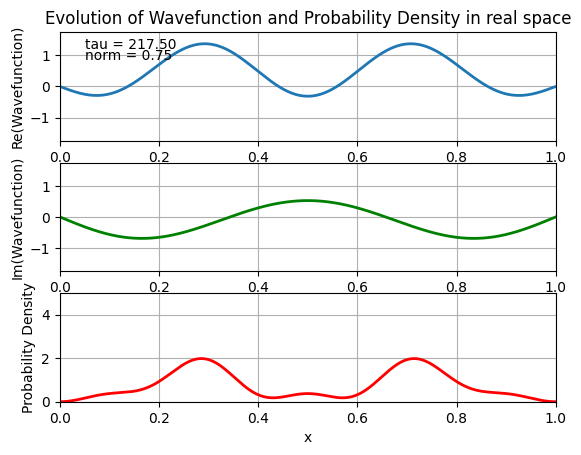

In [152]:
import matplotlib.animation as animation
from IPython.display import HTML
def animate_wavefunction(cn):
    # δημιουργήστε ένα σχήμα με τρια subplots
    fig, (ax1, ax2, ax3) = plt.subplots(3,1)

    # αρχικοποιήστε τρία αντικείμενα γραμμής (ένα σε κάθε άξονα)
    line1, = ax1.plot([], [], lw=2)
    line2, = ax2.plot([], [], lw=2, color='g')
    line3, = ax3.plot([], [], lw=2, color='r')
    line = [line1, line2, line3]

    # οι ίδιες αρχικοποιήσεις αξόνων με πριν (απλά τώρα το κάνουμε και για τους δύο)
    ax1.set_ylim(-1.75, 1.75)
    ax1.set_xlim(0, 1)
    ax1.grid()
    ax1.set_ylabel("Re(Wavefunction)")
    ax1.set_title("Evolution of Wavefunction and Probability Density in real space")

    ax2.set_ylim(-1.75, 1.75)
    ax2.set_xlim(0, 1)
    ax2.grid()
    ax2.set_ylabel("Im(Wavefunction)")

    ax3.set_ylim(0, 5)
    ax3.set_xlim(0, 1)
    ax3.grid()
    ax3.set_xlabel("x")
    ax3.set_ylabel("Probability Density")

    time_text = ax1.text(0.05, 0.95,'',horizontalalignment='left',verticalalignment='top', transform=ax1.transAxes)
    norm_text = ax1.text(0.05, 0.85,'',horizontalalignment='left',verticalalignment='top', transform=ax1.transAxes)
    time_per_frame = 7.5        # έγινε αλλαγή σε 1.5 για να φαίνεται διαφορά στο animation

    def run_init():
        line[0].set_data([], [])
        line[1].set_data([], [])
        line[2].set_data([], [])
        return line
        
    def run(i):
        wf = wavefunction(x, time_per_frame*i, cn)
        y1data = np.real(wf)
        y2data = np.imag(wf)
        y3data = np.abs(wf)**2    # και εδώ έγινε μία αλλαγή λόγω bug

        # ενημερώνουμε τα δεδομένα των τριών αντικειμένων γραμμής
        line[0].set_data(x, y1data)
        line[1].set_data(x, y2data)
        line[2].set_data(x, y3data)
        # Εμφάνιση της τρέχουσας χρονικής στιγμής των κινουμένων σχεδίων
        time_text.set_text('tau = %.2f' % (i*time_per_frame))
        norm_text.set_text('norm = %.2f' % np.real((norm(spacing,wf))))
        return line + [time_text, norm_text]

    ani = animation.FuncAnimation(fig, run, init_func=run_init, frames=30, interval=20, blit=True)

    # ani;
    # plt.show()        # plt.show() δεν δουλεύει για animations: μόνο με το παρακάτω
    return HTML(ani.to_jshtml())

animate_wavefunction(cn)

#### Ερώτηση 5
Τροποποιήστε τον πίνακα συντελεστών, $c_n$, επάνω, έτσι ώστε να κάνετε το animation μιας μοναδικής ιδιοκατάστασης ενέργειας. Περιγράψτε πώς μοιάζουν τα $Re[\Psi(x,\tau)]$, $Im[\Psi(x,\tau)]$ και η πυκνότητα πιθανότητας, $|\Psi(x,\tau)|^2$.

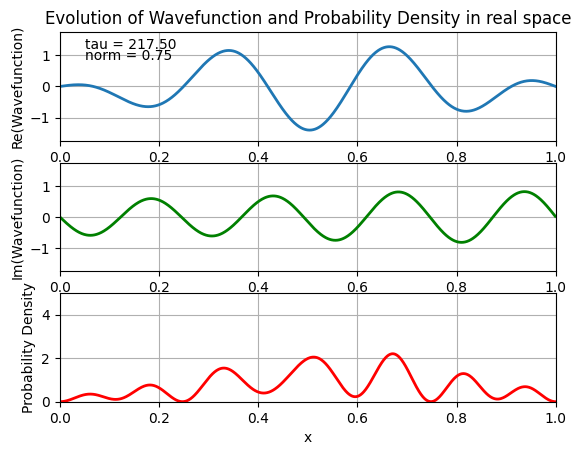

In [153]:
cn2 = np.array([sq4, 0, 0, 0, 0, sq4, 0, sq4, sq4])
animate_wavefunction(cn2)

Η εξέλιξη των κυματοσυναρτήσεων στον χρόνο είναι διαφορετική για τις δύο περιπτώσεις συντελεστών cn. Αλλάζει το πλήθος κορυφών που σχηματίζεται και η ταχύτητα πεπλάτυνσής τους. Αν και χρειάζεται πολλά δευτερόλεπτα compiling για να τρέξει μία περίοδος, με αυτά τα μικρά animation φαίνεται πως οι κατανομές πιθανοτήτων μεταβάλλονται χρονικά.